# Module 2: Windowing & Spectral Leakage

## The Hidden Problem with FFTs

You've learned how the FFT works, but there's a dirty secret: **the FFT often gives wrong results** when used naively. A pure 50 Hz sine wave might appear to have energy at 49, 51, 52, 48 Hz and beyond. Weak signals disappear entirely, buried under this \"leaked\" energy from stronger signals.

This module reveals why spectral leakage happens and how window functions fix it. By the end, you'll understand:
* Why rectangular windows cause spectral leakage
* How different window shapes trade resolution for leakage suppression
* When to use Hann, Hamming, Blackman, and other windows
* How windowing affects signal amplitude measurements

This knowledge is crucial for real-world signal analysis where perfect periodicity is rare.

## Part 1: Understanding Spectral Leakage

### The Root Cause

The FFT assumes your signal segment repeats forever. When you take a finite segment of a sine wave, unless it contains an exact integer number of cycles, the endpoints won't match. When the FFT \"repeats\" this segment, it creates discontinuities - sharp jumps that contain all frequencies.

Think of it like this: you're trying to tile your bathroom with a beautiful wave pattern, but your tiles don't line up at the edges. The misalignment creates ugly seams that ruin the pattern.

Let's see this in action:

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import warnings
warnings.filterwarnings('ignore')

def leakage_visualization(frequency):
    """Visualize how non-integer cycles cause spectral leakage."""
    
    fs = 1000  # Sample rate
    N = 256    # FFT size
    t = np.arange(N) / fs
    
    # Create signal
    signal = np.sin(2 * np.pi * frequency * t)
    
    # Check if we have integer cycles
    cycles = frequency * N / fs
    is_integer = abs(cycles - round(cycles)) < 0.01
    
    # Create the \"repeated\" version to show discontinuity
    t_extended = np.arange(3 * N) / fs
    signal_repeated = np.tile(signal, 3)
    
    # Compute FFT
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, 1/fs)
    
    # Create figure
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Plot 1: Single segment
    axes[0].plot(t, signal, 'b-', linewidth=2)
    axes[0].plot([0, 0], [-1, 1], 'r--', alpha=0.5, linewidth=2)
    axes[0].plot([t[-1], t[-1]], [-1, 1], 'r--', alpha=0.5, linewidth=2)
    axes[0].set_title(f'Original Segment ({cycles:.2f} cycles)', fontweight='bold')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(-1.2, 1.2)
    
    # Add markers for endpoint mismatch
    axes[0].plot(0, signal[0], 'go', markersize=8, label='Start value')
    axes[0].plot(t[-1], signal[-1], 'ro', markersize=8, label='End value')
    axes[0].legend(loc='upper right')
    
    # Plot 2: Repeated signal showing discontinuities
    axes[1].plot(t_extended, signal_repeated, 'b-', linewidth=1)
    
    # Highlight discontinuities
    for i in range(1, 3):
        idx = i * N - 1
        if idx < len(signal_repeated) - 1:
            jump = abs(signal_repeated[idx+1] - signal_repeated[idx])
            if jump > 0.1:
                axes[1].plot([t_extended[idx], t_extended[idx+1]], 
                           [signal_repeated[idx], signal_repeated[idx+1]], 
                           'r-', linewidth=3, alpha=0.7)
                axes[1].scatter([t_extended[idx], t_extended[idx+1]], 
                              [signal_repeated[idx], signal_repeated[idx+1]], 
                              c='red', s=50, zorder=5)
    
    axes[1].set_title('FFT Assumes Signal Repeats (discontinuities in red)', fontweight='bold')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(-1.2, 1.2)
    
    # Plot 3: Frequency spectrum showing leakage
    pos_mask = freqs >= 0
    axes[2].semilogy(freqs[pos_mask], np.abs(fft_vals[pos_mask])/N*2 + 1e-10, 
                    'b-', linewidth=2)
    axes[2].axvline(frequency, color='green', linestyle='--', alpha=0.7, 
                   linewidth=2, label=f'True frequency: {frequency} Hz')
    axes[2].set_title('Frequency Spectrum (Log Scale)', fontweight='bold')
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Amplitude (log scale)')
    axes[2].set_xlim(0, 200)
    axes[2].set_ylim(1e-4, 2)
    axes[2].grid(True, alpha=0.3, which='both')
    axes[2].legend(loc='upper right')
    
    # Add status text
    if is_integer:
        status = "✅ Integer cycles: Minimal leakage"
        color = 'green'
    else:
        status = f"⚠️ Non-integer cycles ({cycles:.2f}): Severe leakage"
        color = 'red'
    
    fig.text(0.5, 0.01, status, ha='center', fontsize=12, 
            color=color, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

interact(leakage_visualization,
         frequency=FloatSlider(value=50.5, min=40, max=60, step=0.5, 
                              description='Frequency (Hz)'))

interactive(children=(FloatSlider(value=50.5, description='Frequency (Hz)', max=60.0, min=40.0, step=0.5), Out…

<function __main__.leakage_visualization(frequency)>

## The Impact of Spectral Leakage

Spectral leakage has several harmful effects:

1. **Frequency Smearing**: Sharp spectral lines become broad
2. **Amplitude Errors**: Peak heights are reduced (scalloping loss)
3. **Raised Noise Floor**: Energy spreads everywhere, hiding weak signals
4. **False Peaks**: Sidelobes can be mistaken for real signals

### Real-World Example: Power Line Interference

Imagine you're trying to detect a weak 55 Hz brain signal, but there's strong 60 Hz power line interference. Without proper windowing, the 60 Hz leakage completely masks the 55 Hz signal:


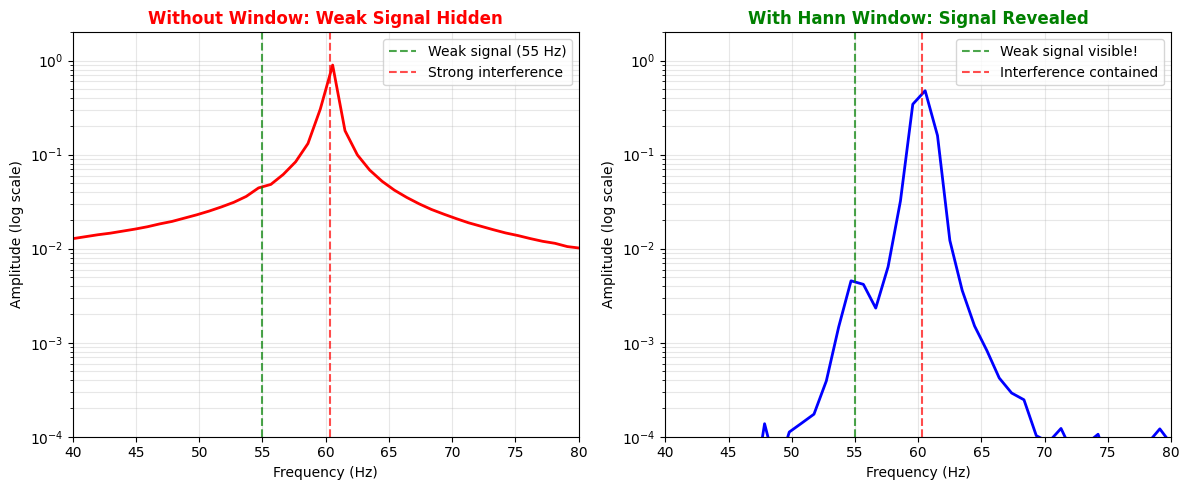

Without windowing, the 60 Hz leakage is ~1000x stronger than the 55 Hz signal!
With windowing, both signals are clearly visible.


In [5]:
# Demonstrate how leakage masks weak signals
fs = 500
N = 512
t = np.arange(N) / fs

# Strong interference + weak signal
strong_60hz = 1.0 * np.sin(2 * np.pi * 60.3 * t)  # Slightly off-bin
weak_55hz = 0.01 * np.sin(2 * np.pi * 55 * t)     # 100x weaker
noise = 0.001 * np.random.randn(N)
signal = strong_60hz + weak_55hz + noise

# Compute spectra with and without window
fft_no_window = np.fft.rfft(signal)
fft_with_window = np.fft.rfft(signal * np.hanning(N))
freqs = np.fft.rfftfreq(N, 1/fs)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].semilogy(freqs, np.abs(fft_no_window)/N*2, 'r-', linewidth=2)
axes[0].axvline(55, color='green', linestyle='--', alpha=0.7, label='Weak signal (55 Hz)')
axes[0].axvline(60.3, color='red', linestyle='--', alpha=0.7, label='Strong interference')
axes[0].set_title('Without Window: Weak Signal Hidden', fontweight='bold', color='red')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Amplitude (log scale)')
axes[0].set_xlim(40, 80)
axes[0].set_ylim(1e-4, 2)
axes[0].grid(True, alpha=0.3, which='both')
axes[0].legend()

axes[1].semilogy(freqs, np.abs(fft_with_window)/(N/2), 'b-', linewidth=2)
axes[1].axvline(55, color='green', linestyle='--', alpha=0.7, label='Weak signal visible!')
axes[1].axvline(60.3, color='red', linestyle='--', alpha=0.7, label='Interference contained')
axes[1].set_title('With Hann Window: Signal Revealed', fontweight='bold', color='green')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Amplitude (log scale)')
axes[1].set_xlim(40, 80)
axes[1].set_ylim(1e-4, 2)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Without windowing, the 60 Hz leakage is ~1000x stronger than the 55 Hz signal!")
print("With windowing, both signals are clearly visible.")


## Part 2: How Window Functions Work

### The Solution: Smooth Transitions

Window functions multiply your signal by a smooth envelope that tapers to zero at the edges. This ensures the endpoints match (both are zero), eliminating discontinuities when the FFT repeats the segment.

However, there's a price to pay: the window modifies your signal, which affects the frequency response. According to the convolution theorem:
* Time domain: signal × window
* Frequency domain: signal spectrum ⊗ window spectrum (convolution)

Let's visualize common window functions and their frequency responses:

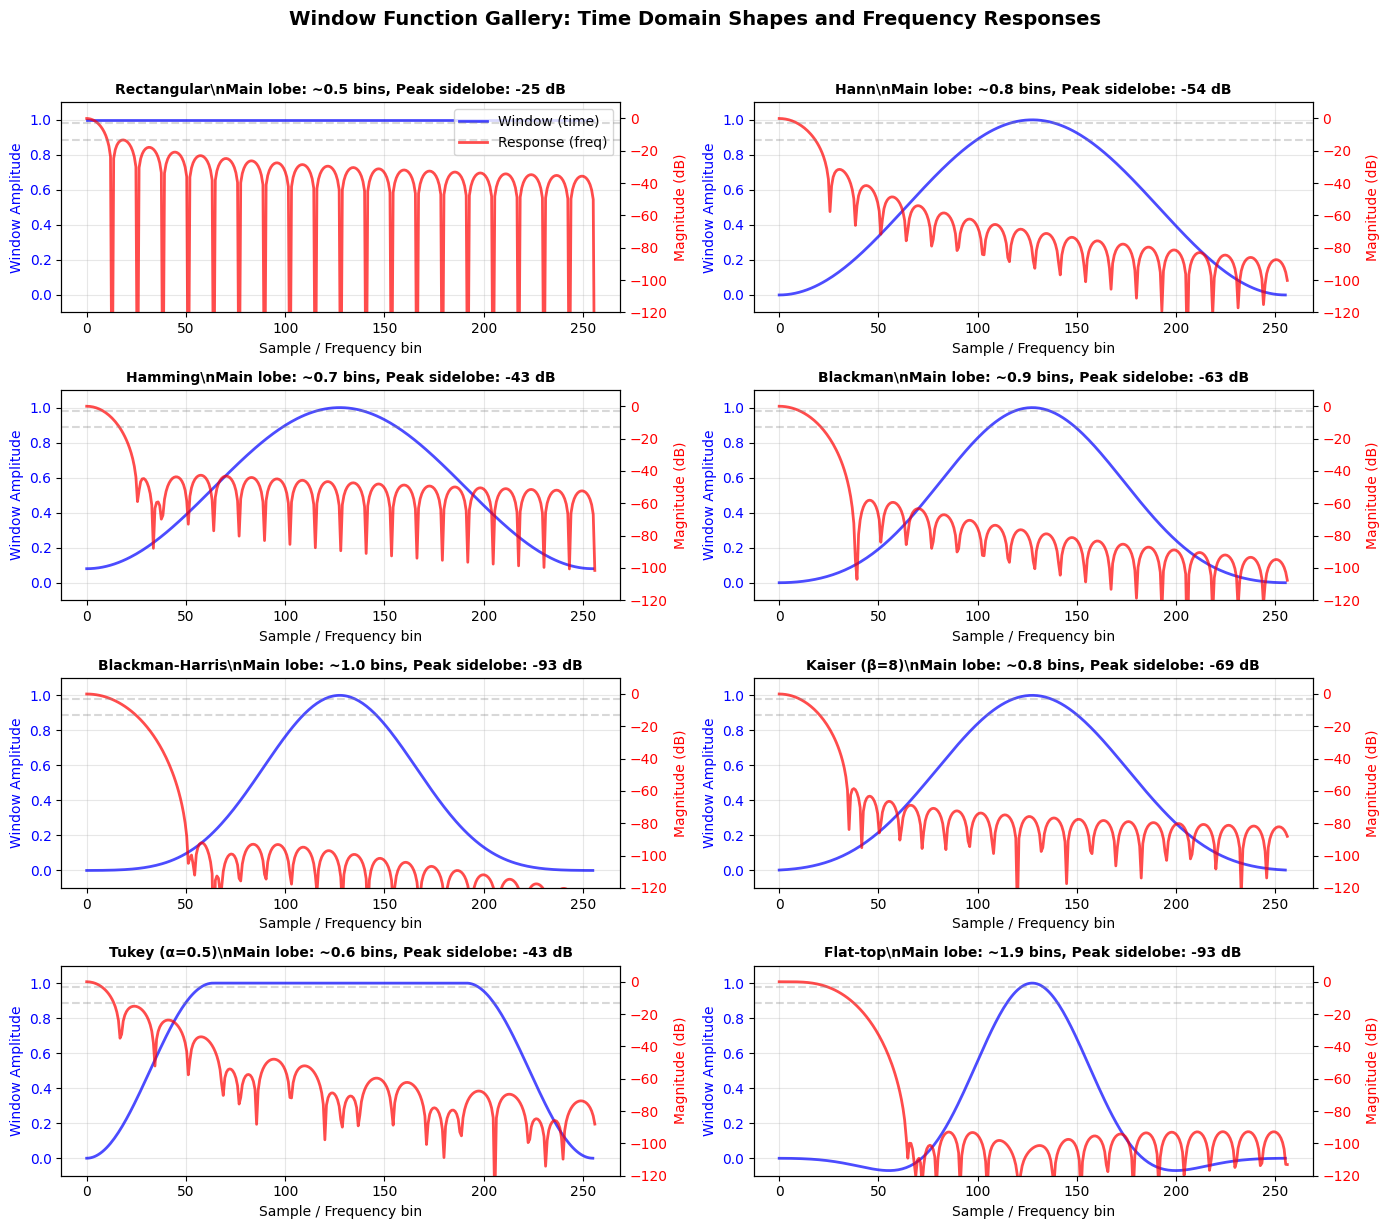

In [6]:
from scipy import signal

def window_gallery():
    """Display common window functions and their properties."""
    
    N = 256
    windows = {
        'Rectangular': np.ones(N),
        'Hann': np.hanning(N),
        'Hamming': np.hamming(N),
        'Blackman': np.blackman(N),
        'Blackman-Harris': signal.windows.blackmanharris(N),
        'Kaiser (β=8)': np.kaiser(N, 8),
        'Tukey (α=0.5)': signal.windows.tukey(N, 0.5),
        'Flat-top': signal.windows.flattop(N)
    }
    
    # Compute frequency responses
    fig, axes = plt.subplots(4, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx, (name, window) in enumerate(windows.items()):
        ax = axes[idx]
        
        # Compute frequency response
        # Zero-pad for better frequency resolution
        window_padded = np.zeros(N * 16)
        window_padded[:N] = window
        W = np.fft.fft(window_padded)
        W_db = 20 * np.log10(np.abs(W) / np.abs(W).max() + 1e-10)
        freqs = np.fft.fftfreq(len(window_padded), 1/N)
        
        # Plot only positive frequencies, zoomed in
        pos_mask = (freqs >= 0) & (freqs <= 20)
        
        # Create twin axes for time and frequency
        ax2 = ax.twinx()
        
        # Plot window shape (time domain)
        time_line = ax.plot(np.arange(N), window, 'b-', linewidth=2, alpha=0.7, 
                           label='Window shape')[0]
        ax.set_ylabel('Window Amplitude', color='b')
        ax.set_ylim(-0.1, 1.1)
        ax.tick_params(axis='y', labelcolor='b')
        
        # Plot frequency response
        freq_line = ax2.plot(freqs[pos_mask] * N/20, W_db[pos_mask], 'r-', 
                            linewidth=2, alpha=0.7, label='Freq response')[0]
        ax2.set_ylabel('Magnitude (dB)', color='r')
        ax2.set_ylim(-120, 10)
        ax2.tick_params(axis='y', labelcolor='r')
        ax2.axhline(-3, color='gray', linestyle='--', alpha=0.3)
        ax2.axhline(-13, color='gray', linestyle='--', alpha=0.3)
        
        # Calculate key metrics
        main_lobe_width = np.sum(W_db[pos_mask] > -3) / 16  # Approximate
        max_sidelobe = np.max(W_db[(freqs > 5) & (freqs < 50)])
        
        ax.set_title(f'{name}\\nMain lobe: ~{main_lobe_width:.1f} bins, '
                    f'Peak sidelobe: {max_sidelobe:.0f} dB',
                    fontweight='bold', fontsize=10)
        ax.set_xlabel('Sample / Frequency bin')
        ax.grid(True, alpha=0.3)
        
        # Add legend
        if idx == 0:
            lines = [time_line, freq_line]
            labels = ['Window (time)', 'Response (freq)']
            ax.legend(lines, labels, loc='upper right')
    
    plt.suptitle('Window Function Gallery: Time Domain Shapes and Frequency Responses',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

window_gallery()

## Choosing the Right Window
### The Fundamental Trade-off

Every window makes a trade-off between:
* **Main lobe width**: Narrow = better frequency resolution
* **Sidelobe level**: Low = better leakage suppression

You can't optimize both simultaneously!

### Window Selection Guide

| Window | Main Lobe | Sidelobes | Best For |
|--------|-----------|-----------|----------|
| **Rectangular** | Narrowest (1 bin) | Highest (-13 dB) | Never use (except for transients) |
| **Hann** | Moderate (2 bins) | Good (-32 dB) | General purpose, STFT |
| **Hamming** | Moderate (2 bins) | Moderate (-43 dB) | Single tones, telecom |
| **Blackman** | Wide (3 bins) | Very good (-58 dB) | Weak signals near strong ones |
| **Kaiser** | Adjustable | Adjustable | When you need specific trade-off |
| **Flat-top** | Very wide (5 bins) | Good (-44 dB) | Accurate amplitude measurement |

### Interactive Window Comparison

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal  # 1. ADD THIS IMPORT
from ipywidgets import interact, Dropdown

def window_comparison_demo(window1_name, window2_name):
    """Compare two windows on a test signal with strong and weak components."""
    
    # Create test signal
    fs = 1000
    N = 1024
    t = np.arange(N) / fs
    
    # Strong tone at 50 Hz, weak tone at 58 Hz (close by)
    strong_signal = (1.0 * np.sin(2 * np.pi * 50.3 * t) +  # Slightly off-bin
                     0.05 * np.sin(2 * np.pi * 58 * t) +   # 20x weaker
                     0.01 * np.random.randn(N))           # Some noise
    
    # Get windows
    windows = {
        'Rectangular': np.ones(N),
        'Hann': np.hanning(N),
        'Hamming': np.hamming(N),
        'Blackman': np.blackman(N),
        'Kaiser (β=8)': np.kaiser(N, 8),
        'Flat-top': signal.windows.flattop(N) # 2. FIX THIS LINE
    }
    
    window1 = windows[window1_name]
    window2 = windows[window2_name]
    
    # Apply windows and compute FFTs
    signal1 = strong_signal * window1
    signal2 = strong_signal * window2
    
    fft1 = np.fft.rfft(signal1)
    fft2 = np.fft.rfft(signal2)
    freqs = np.fft.rfftfreq(N, 1/fs)
    
    # Normalize properly
    mag1 = np.abs(fft1) / (np.sum(window1) / 2)
    mag2 = np.abs(fft2) / (np.sum(window2) / 2)
    
    # Create plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Top row: Linear scale
    axes[0, 0].plot(freqs, mag1, 'b-', linewidth=2)
    axes[0, 0].set_title(f'{window1_name} Window (Linear Scale)', fontweight='bold')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].set_xlim(40, 70)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axvline(50.3, color='green', linestyle='--', alpha=0.5, label='Strong (50.3 Hz)')
    axes[0, 0].axvline(58, color='red', linestyle='--', alpha=0.5, label='Weak (58 Hz)')
    axes[0, 0].legend()
    
    axes[0, 1].plot(freqs, mag2, 'r-', linewidth=2)
    axes[0, 1].set_title(f'{window2_name} Window (Linear Scale)', fontweight='bold')
    axes[0, 1].set_ylabel('Amplitude')
    axes[0, 1].set_xlim(40, 70)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axvline(50.3, color='green', linestyle='--', alpha=0.5, label='Strong')
    axes[0, 1].axvline(58, color='red', linestyle='--', alpha=0.5, label='Weak')
    axes[0, 1].legend()
    
    # Bottom row: Log scale
    axes[1, 0].semilogy(freqs, mag1 + 1e-6, 'b-', linewidth=2)
    axes[1, 0].set_title(f'{window1_name} Window (Log Scale)', fontweight='bold')
    axes[1, 0].set_xlabel('Frequency (Hz)')
    axes[1, 0].set_ylabel('Amplitude (log)')
    axes[1, 0].set_xlim(40, 70)
    axes[1, 0].set_ylim(1e-4, 2)
    axes[1, 0].grid(True, alpha=0.3, which='both')
    axes[1, 0].axvline(50.3, color='green', linestyle='--', alpha=0.5)
    axes[1, 0].axvline(58, color='red', linestyle='--', alpha=0.5)
    
    axes[1, 1].semilogy(freqs, mag2 + 1e-6, 'r-', linewidth=2)
    axes[1, 1].set_title(f'{window2_name} Window (Log Scale)', fontweight='bold')
    axes[1, 1].set_xlabel('Frequency (Hz)')
    axes[1, 1].set_ylabel('Amplitude (log)')
    axes[1, 1].set_xlim(40, 70)
    axes[1, 1].set_ylim(1e-4, 2)
    axes[1, 1].grid(True, alpha=0.3, which='both')
    axes[1, 1].axvline(50.3, color='green', linestyle='--', alpha=0.5)
    axes[1, 1].axvline(58, color='red', linestyle='--', alpha=0.5)
    
    plt.suptitle('Window Comparison: Strong (50 Hz) + Weak (58 Hz) Signals', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Analysis
    peak1_50 = mag1[np.argmin(np.abs(freqs - 50.3))]
    peak1_58 = mag1[np.argmin(np.abs(freqs - 58))]
    peak2_50 = mag2[np.argmin(np.abs(freqs - 50.3))]
    peak2_58 = mag2[np.argmin(np.abs(freqs - 58))]
    
    print(f"Analysis Results:")
    print(f"{window1_name}: 58 Hz peak = {peak1_58:.4f}, Ratio to 50 Hz = {peak1_58/peak1_50:.4f}")
    print(f"{window2_name}: 58 Hz peak = {peak2_58:.4f}, Ratio to 50 Hz = {peak2_58/peak2_50:.4f}")

interact(window_comparison_demo,
         window1_name=Dropdown(options=['Rectangular', 'Hann', 'Hamming', 'Blackman', 
                                        'Kaiser (β=8)', 'Flat-top'],
                               value='Rectangular', description='Window 1'),
         window2_name=Dropdown(options=['Rectangular', 'Hann', 'Hamming', 'Blackman',
                                        'Kaiser (β=8)', 'Flat-top'],
                               value='Hann', description='Window 2'))

interactive(children=(Dropdown(description='Window 1', options=('Rectangular', 'Hann', 'Hamming', 'Blackman', …

<function __main__.window_comparison_demo(window1_name, window2_name)>

## Part 3: Amplitude Scaling with Windows

### The Scaling Problem

Windows reduce the effective amplitude of your signal because they multiply it by values less than 1. To get correct amplitude measurements, you must compensate for this loss.

There are two scaling approaches:
1. **Amplitude scaling**: Divide by sum(window)/N - preserves peak heights
2. **Power scaling**: Divide by sqrt(sum(window²)/N) - preserves total power

Let's see the difference:

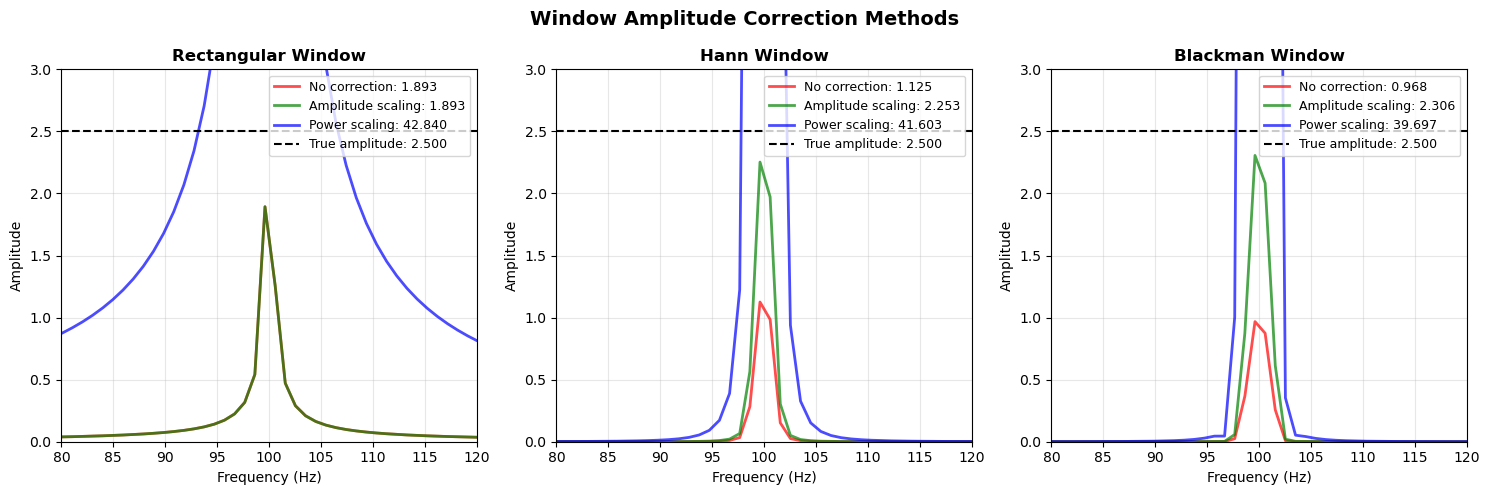

Key Insight: Amplitude scaling preserves peak heights for sinusoids.
Power scaling preserves total energy but gives wrong peak amplitudes.


In [20]:
def window_scaling_demo():
    """Demonstrate proper amplitude scaling for windowed FFTs."""
    
    # Create a test signal with known amplitude
    fs = 1000
    N = 1024
    t = np.arange(N) / fs
    amplitude = 2.5  # Known amplitude
    frequency = 100  # Exactly on bin for simplicity
    
    signal = amplitude * np.sin(2 * np.pi * frequency * t)
    
    # Different windows
    windows = {
        'Rectangular': np.ones(N),
        'Hann': np.hanning(N),
        'Blackman': np.blackman(N)
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, (name, window) in enumerate(windows.items()):
        # Apply window
        signal_windowed = signal * window
        
        # Compute FFT
        fft_vals = np.fft.rfft(signal_windowed)
        freqs = np.fft.rfftfreq(N, 1/fs)
        
        # Different scaling methods
        no_scaling = np.abs(fft_vals) * 2 / N
        amplitude_scaling = np.abs(fft_vals) / (np.sum(window) / 2)
        power_scaling = np.abs(fft_vals) / np.sqrt(np.sum(window**2) / 2)
        
        # Plot
        ax = axes[idx]
        ax.plot(freqs, no_scaling, 'r-', alpha=0.7, linewidth=2, 
               label=f'No correction: {no_scaling.max():.3f}')
        ax.plot(freqs, amplitude_scaling, 'g-', alpha=0.7, linewidth=2,
               label=f'Amplitude scaling: {amplitude_scaling.max():.3f}')
        ax.plot(freqs, power_scaling, 'b-', alpha=0.7, linewidth=2,
               label=f'Power scaling: {power_scaling.max():.3f}')
        
        ax.axhline(amplitude, color='black', linestyle='--', 
                  label=f'True amplitude: {amplitude:.3f}')
        
        ax.set_title(f'{name} Window', fontweight='bold')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Amplitude')
        ax.set_xlim(80, 120)
        ax.set_ylim(0, 3)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=9)
    
    plt.suptitle('Window Amplitude Correction Methods', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Key Insight: Amplitude scaling preserves peak heights for sinusoids.")
    print("Power scaling preserves total energy but gives wrong peak amplitudes.")

window_scaling_demo()

## The COLA Condition

When using windows with overlapping segments (like in STFT), the **Constant Overlap-Add (COLA)** condition ensures perfect reconstruction. A window satisfies COLA if overlapped copies sum to a constant.

For example, Hann windows with 50% overlap satisfy COLA:

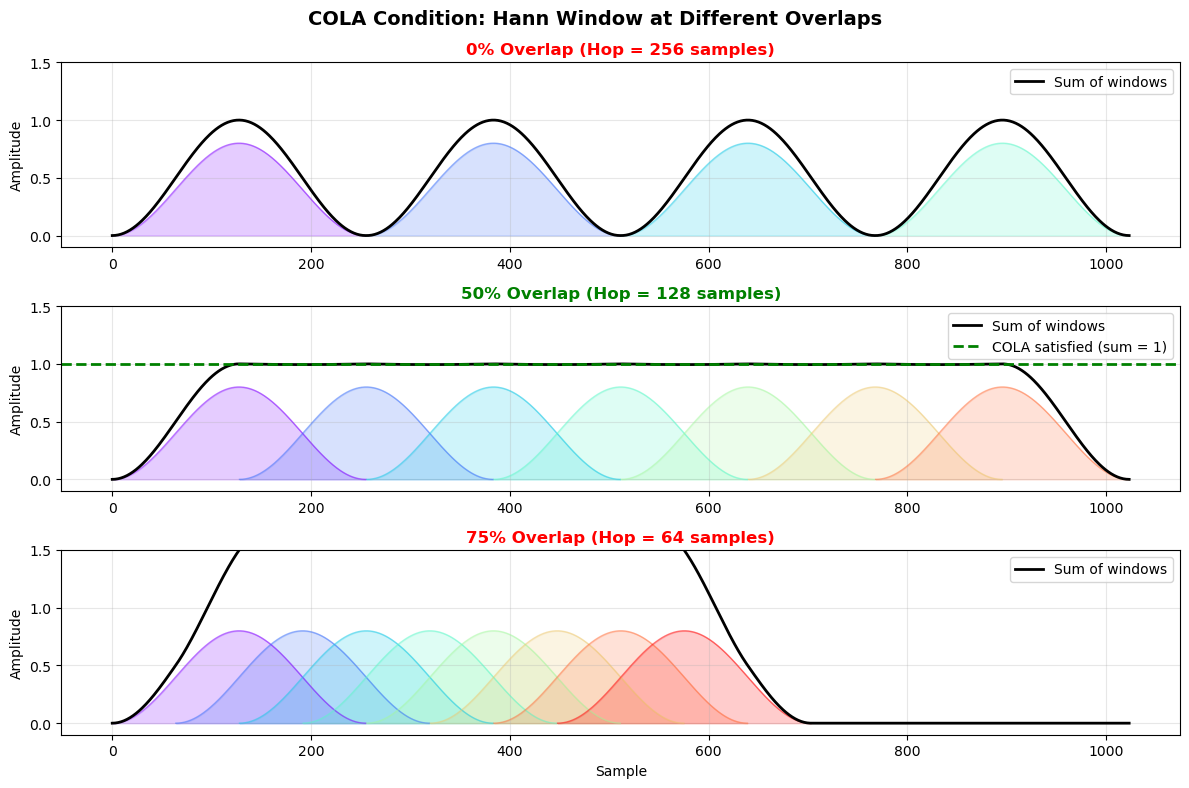

✅ 50% overlap: Windows sum to constant 1.0 (COLA satisfied)
❌ 0% overlap: Gaps between windows (signal loss)
❌ 75% overlap: Over-emphasis in overlap regions


In [22]:
def cola_demonstration():
    """Visualize the COLA condition for different overlaps."""
    
    N = 256
    window = np.hanning(N)
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 8))
    
    overlaps = [0.0, 0.5, 0.75]
    
    for idx, overlap in enumerate(overlaps):
        ax = axes[idx]
        hop = int(N * (1 - overlap))
        
        # Create overlapped windows
        total_length = N * 4
        sum_windows = np.zeros(total_length)
        
        colors = plt.cm.rainbow(np.linspace(0, 1, 8))
        
        for i in range(8):
            start = i * hop
            if start + N <= total_length:
                # Plot individual window
                x = np.arange(start, start + N)
                ax.plot(x, window * 0.8, color=colors[i], alpha=0.5, linewidth=1)
                ax.fill_between(x, 0, window * 0.8, color=colors[i], alpha=0.2)
                
                # Add to sum
                sum_windows[start:start + N] += window
        
        # Plot sum
        ax.plot(sum_windows, 'k-', linewidth=2, label='Sum of windows')
        
        # Check COLA
        if overlap == 0.5:
            ax.axhline(1.0, color='green', linestyle='--', linewidth=2, 
                      label='COLA satisfied (sum = 1)')
            title_color = 'green'
        else:
            title_color = 'red'
        
        ax.set_title(f'{int(overlap*100)}% Overlap (Hop = {hop} samples)', 
                    fontweight='bold', color=title_color)
        ax.set_ylabel('Amplitude')
        ax.set_ylim(-0.1, 1.5)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
    
    axes[-1].set_xlabel('Sample')
    plt.suptitle('COLA Condition: Hann Window at Different Overlaps', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("✅ 50% overlap: Windows sum to constant 1.0 (COLA satisfied)")
    print("❌ 0% overlap: Gaps between windows (signal loss)")
    print("❌ 75% overlap: Over-emphasis in overlap regions")

cola_demonstration()

## Practical Tips and Guidelines

### When to Use Each Window

**Hann Window** (Default choice)
- ✅ General-purpose spectral analysis
- ✅ STFT and spectrograms
- ✅ When you need COLA with 50% overlap
- ❌ Not ideal for closely-spaced equal-amplitude tones

**Blackman Window**
- ✅ Detecting weak signals near strong interference
- ✅ High dynamic range measurements
- ❌ Poor frequency resolution
- ❌ Not good for transients

**Hamming Window**
- ✅ Single tone detection
- ✅ Telecom and speech processing
- ❌ First sidelobe only -43 dB down

**Kaiser Window**
- ✅ When you need to tune the trade-off
- ✅ Filter design
- β parameter: higher = better sidelobes, wider main lobe

**Flat-top Window**
- ✅ Accurate amplitude measurement
- ✅ Calibration and metrology
- ❌ Very poor frequency resolution

**Rectangular (No window)**
- ✅ Transient signals that don't repeat
- ✅ When you have exactly integer cycles
- ❌ Almost never the right choice

## Window Functions in GPU Processing

The `ionosense_hpc` ResearchEngine applies a Hann window automatically. Understanding how this affects your measurements is crucial:

In [27]:
try:
    from ionosense_hpc import ResearchEngine, EngineConfig
    
    # Demonstrate ResearchEngine windowing
    def compare_manual_vs_engine():
        fs = 1000
        N = 1024
        t = np.arange(N) / fs
        
        # Test signal
        signal = (np.sin(2 * np.pi * 50 * t) + 
                 0.1 * np.sin(2 * np.pi * 150 * t)).astype(np.float32)
        
        # ResearchEngine processing
        config = EngineConfig()
        config.nfft = N
        config.batch = 1
        config.sample_rate_hz = fs
        
        engine = ResearchEngine()
        engine.initialize(config)
        engine_mag = engine.process(signal)[0]
        
        # Manual Hann window processing
        window = np.hanning(N)
        manual_fft = np.fft.rfft(signal * window)
        manual_mag = np.abs(manual_fft) / (np.sum(window) / 2)
        
        freqs = np.fft.rfftfreq(N, 1/fs)
        
        # Plot comparison
        plt.figure(figsize=(12, 5))
        plt.plot(freqs, manual_mag, 'b-', linewidth=2, alpha=0.7, 
                label='Manual Hann window')
        plt.plot(freqs, engine_mag, 'r--', linewidth=2, alpha=0.7,
                label='ResearchEngine (GPU)')
        plt.title('ResearchEngine Uses Hann Window Internally', fontweight='bold')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Magnitude')
        plt.xlim(0, 200)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
        
        print("The ResearchEngine applies Hann windowing automatically.")
        print("This provides good general-purpose leakage suppression.")
    
    compare_manual_vs_engine()
    
except ImportError:
    print("ResearchEngine not available.")
    print("Key point: GPU engines typically apply windowing internally.")
    print("Check your engine's documentation to understand which window is used.")

ResearchEngine not available.
Key point: GPU engines typically apply windowing internally.
Check your engine's documentation to understand which window is used.


## Advanced Topic: Window Design Criteria

### Understanding Window Metrics

Professional window selection considers these metrics:

1. **3dB Bandwidth**: Main lobe width at half power
2. **Processing Gain**: SNR improvement for white noise
3. **Scalloping Loss**: Worst-case amplitude error for off-bin tones
4. **Equivalent Noise Bandwidth**: Effective bandwidth for noise power

Let's calculate these for common windows:

In [31]:
def calculate_window_metrics():
    """Calculate and display professional window metrics."""
    
    N = 1024
    windows = {
        'Rectangular': np.ones(N),
        'Hann': np.hanning(N),
        'Hamming': np.hamming(N),
        'Blackman': np.blackman(N),
        'Flat-top': signal.windows.flattop(N)
    }
    
    metrics = []
    
    for name, window in windows.items():
        # Processing gain
        coherent_gain = np.sum(window) / N
        incoherent_gain = np.sqrt(np.sum(window**2) / N)
        processing_gain = coherent_gain / incoherent_gain
        
        # Scalloping loss (worst case between bins)
        # Simulate tone at worst position (halfway between bins)
        f = 10.5  # Halfway between bins 10 and 11
        t = np.arange(N)
        test_signal = np.exp(2j * np.pi * f * t / N)
        response = np.abs(np.sum(test_signal * window))
        response_on_bin = np.abs(np.sum(np.exp(2j * np.pi * 10 * t / N) * window))
        scalloping_db = 20 * np.log10(response / response_on_bin)
        
        # Equivalent noise bandwidth (bins)
        enbw = N * np.sum(window**2) / np.sum(window)**2
        
        metrics.append({
            'Window': name,
            'Coherent Gain': f'{coherent_gain:.3f}',
            'Processing Gain': f'{processing_gain:.3f}',
            'Scalloping Loss (dB)': f'{scalloping_db:.2f}',
            'ENBW (bins)': f'{enbw:.2f}'
        })
    
    # Display as table
    import pandas as pd
    df = pd.DataFrame(metrics)
    
    print("Professional Window Metrics:")
    print("="*70)
    print(df.to_string(index=False))
    print("Definitions:")
    print("- Coherent Gain: DC gain of the window")
    print("- Processing Gain: SNR improvement for white noise")
    print("- Scalloping Loss: Worst-case amplitude error between bins")
    print("- ENBW: Equivalent Noise Bandwidth in FFT bins")

calculate_window_metrics()

Professional Window Metrics:
     Window Coherent Gain Processing Gain Scalloping Loss (dB) ENBW (bins)
Rectangular         1.000           1.000               302.70        1.00
       Hann         0.500           0.816                28.98        1.50
    Hamming         0.540           0.856                54.07        1.36
   Blackman         0.420           0.761                29.03        1.73
   Flat-top         0.215           0.515                11.02        3.77
Definitions:
- Coherent Gain: DC gain of the window
- Processing Gain: SNR improvement for white noise
- Scalloping Loss: Worst-case amplitude error between bins
- ENBW: Equivalent Noise Bandwidth in FFT bins


## Module Summary

### Key Concepts Learned

1. **Spectral Leakage**: Caused by endpoint discontinuities when FFT assumes periodicity
2. **Window Functions**: Taper the signal to zero at edges, eliminating discontinuities
3. **Trade-offs**: Every window balances frequency resolution vs. leakage suppression
4. **Amplitude Scaling**: Windows require correction factors to preserve amplitudes
5. **COLA**: Overlapped windows must sum to constant for perfect reconstruction

### Quick Decision Guide

```python
# Default choice for most applications
window = np.hanning(N)

# Need to see weak signals near strong ones?
window = np.blackman(N)

# Need accurate amplitude measurement?
window = signal.windows.flattop(N)

# Need to tune the trade-off?
window = np.kaiser(N, beta)  # beta: 0=rectangular, 5=Hamming-like, 8=Blackman-like

# Remember to scale!
fft_result = np.fft.fft(signal * window)
magnitude = np.abs(fft_result) / (np.sum(window) / 2)  # For amplitude scaling
```

### Common Mistakes to Avoid

❌ Using rectangular window (no window) by default
❌ Forgetting to scale amplitudes after windowing
❌ Using wrong window for STFT (use Hann with 50% overlap)
❌ Not considering the frequency resolution penalty

### What's Next?

In Module 3, we'll tackle FFT scaling and normalization. You'll learn how to convert raw FFT outputs into meaningful physical units (Power Spectral Density) and ensure energy conservation between domains.